# Fraud Detection Model Fintech MLOps Stack
## Notebook 3 Model Training and Evaluation

This notebook covers Stages 5 and 6 of our fraud detection pipeline.

Stage 5 builds the stacking ensemble three base models (XGBoost, Random Forest, and Logistic Regression) whose predictions are combined by a Logistic Regression meta-learner using sklearn's StackingClassifier. This gives us the combined power of gradient boosting, bagging, and linear classification in one model.

Stage 6 evaluates the ensemble on the untouched 20% test set using AUC-ROC, F1-Score, confusion matrix, and precision-recall curve. We then tune the classification threshold using predict_proba to find the optimal decision boundary that maximises F1-Score for fraud detection.

By the end of this notebook we have a fully trained, evaluated, and threshold-tuned ensemble model ready for serialisation and API deployment.

## Imports and Setup

#### We import all libraries needed for model training, evaluation, and serialisation. We also reload and reapply all preprocessing steps from Notebook 2 so this notebook is fully self-contained and independently runnable.

In [1]:
# Core libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Base models 
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# Preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

# Evaluation metrics 
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    ConfusionMatrixDisplay
)

# Display settings 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("All libraries imported successfully.")

All libraries imported successfully.


## Data Loading and Preprocessing

#### We reload the raw dataset and reapply all preprocessing steps from Notebook 2 duplicate removal, feature engineering, train/test split, RobustScaler, and SMOTE. This ensures Notebook 3 is fully self-contained and independently runnable without depending on any in-memory state from previous notebooks.

In [2]:
# Load and clean dataset 
df = pd.read_csv('../data/creditcard.csv')
df = df.drop_duplicates()

# Feature engineering
df['hour'] = (df['Time'] / 3600) % 24
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['amount_log'] = np.log1p(df['Amount'])
df = df.drop(['Time', 'Amount', 'hour'], axis=1, errors='ignore')

# Split features and target 
X = df.drop('Class', axis=1)
y = df['Class']

# Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features 
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Apply SMOTE to training set only 
smote = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Confirm everything is ready to move on to modeling 
print("Preprocessing complete.")
print(f"Training shape after SMOTE:  {X_train_res.shape}")
print(f"Testing shape:               {X_test_scaled.shape}")
print(f"Training class distribution: {dict(pd.Series(y_train_res).value_counts())}")
print(f"Testing class distribution:  {dict(pd.Series(y_test).value_counts())}")

Preprocessing complete.
Training shape after SMOTE:  (453204, 31)
Testing shape:               (56746, 31)
Training class distribution: {0: 226602, 1: 226602}
Testing class distribution:  {0: 56651, 1: 95}


## Building the Stacking Ensemble

#### Instead of relying on a single model, we are building a Stacking Ensemble. This is a "team" of models with different strengths:

#### XGBoost: A Gradient Boosting machine that excels at finding complex, non-linear patterns in the features.

#### Random Forest: A Bagging model that is highly robust to outliers and prevents overfitting by averaging multiple decision trees.

#### The Meta-Learner (Logistic Regression): This "boss" model doesn't look at the transaction data. Instead, it looks at the predictions of the three models above and learns who to trust more in specific scenarios.


In [4]:
# Define the Base Models (The Team)
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)),
]

# 2. Define the Meta-Learner (The Boss)
meta_learner = LogisticRegression()

# 3. Initialize the Stacking Classifier
# cv=5 means it uses 5-fold cross-validation to prepare the meta-learner
ensemble_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1
)

# 4. Train the Ensemble
print("Training the Stacking Ensemble... (This may take 2-5 minutes)")
ensemble_model.fit(X_train_res, y_train_res)

print("Ensemble training complete.")


Training the Stacking Ensemble... (This may take 2-5 minutes)


/Users/mac/Documents/FraudDetection/venv/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Ensemble training complete.


## Model Evaluation and Threshold Tuning

#### We evaluate the trained ensemble on the untouched 20% test set. We never touched this data during training or SMOTE it represents genuinely unseen transactions.

### We use four evaluation tools:

#### **AUC-ROC** — measures the model's ability to rank fraud above legitimate across all possible thresholds. A score of 1.0 is perfect, 0.5 is random guessing.

#### **F1-Score** — the harmonic mean of precision and recall. For imbalanced fraud detection, F1 is more informative than accuracy because a model that predicts everything as legitimate gets 99.83% accuracy but catches zero fraud.

#### **Confusion Matrix** — shows exactly how many fraud cases we caught (true positives), missed (false negatives), and how many legitimate transactions we wrongly flagged (false positives).

#### **Threshold Tuning** - sklearn's predict_proba returns a fraud probability between 0 and 1. The default decision boundary is 0.5  anything above 0.5 is classified as fraud. We sweep the threshold to find the value that maximises F1-Score for our specific class distribution.

ENSEMBLE MODEL TEST SET RESULTS
AUC-ROC Score:  0.9755
F1-Score:       0.8457

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.93      0.78      0.85        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746



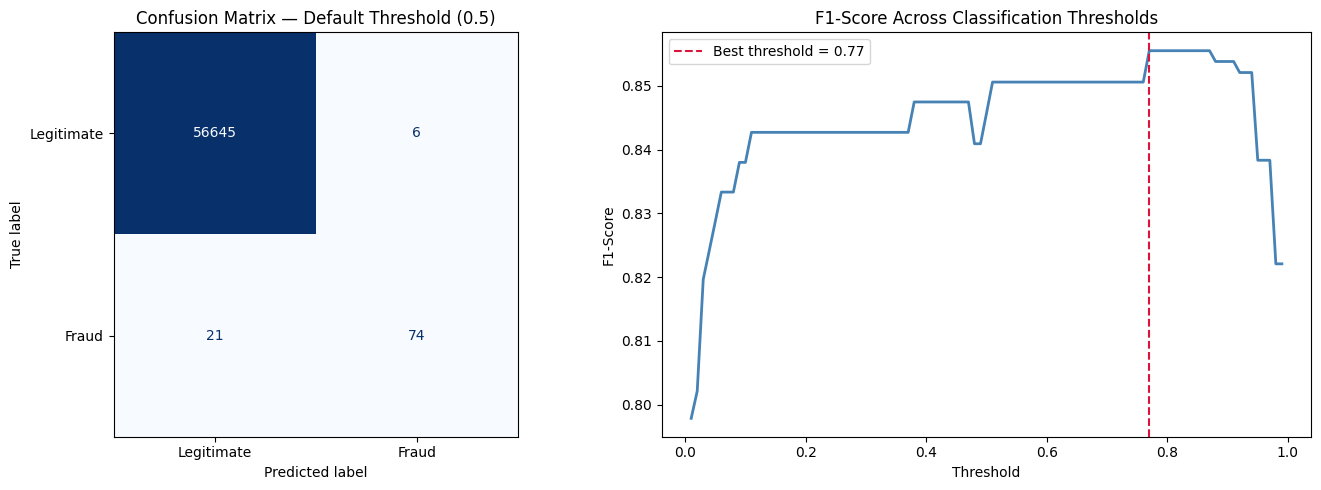


Default threshold F1:  0.8457
Best threshold:        0.77
Best threshold F1:     0.8555


In [5]:
# Generate predictions 
y_pred = ensemble_model.predict(X_test_scaled)
y_prob = ensemble_model.predict_proba(X_test_scaled)[:, 1]

# Core metrics 
auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("ENSEMBLE MODEL TEST SET RESULTS")
print("=" * 50)
print(f"AUC-ROC Score:  {auc:.4f}")
print(f"F1-Score:       {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# Confusion matrix 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Default Threshold (0.5)')

# Threshold tuning 
thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

axes[1].plot(thresholds, f1_scores, color='steelblue', linewidth=2)
axes[1].axvline(x=best_threshold, color='crimson', linestyle='--', linewidth=1.5,
                label=f'Best threshold = {best_threshold:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score Across Classification Thresholds')
axes[1].legend()

plt.tight_layout()
os.makedirs('../Plots', exist_ok=True)
plt.savefig('../Plots/evaluation_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDefault threshold F1:  {f1:.4f}")
print(f"Best threshold:        {best_threshold:.2f}")
print(f"Best threshold F1:     {best_f1:.4f}")

## Model Serialisation

### We serialise three artefacts to disk using joblib:

#### **ensemble_model** — the fully trained StackingClassifier
#### **scaler** — the RobustScaler fitted on training data only
#### **threshold** — the optimal decision boundary (0.77) found during threshold tuning

#### These three files are everything the FastAPI service needs to score a new transaction at inference time. joblib is preferred over pickle for sklearn and numpy objects because it handles large arrays more efficiently using memory-mapped files.

In [ ]:
#  Create models directory 
os.makedirs('../models', exist_ok=True)

#  Serialise artefacts 
joblib.dump(ensemble_model, '../models/ensemble_model.joblib')
joblib.dump(scaler,         '../models/scaler.joblib')
joblib.dump(best_threshold, '../models/threshold.joblib')

#  Verify files were written 
artefacts = ['ensemble_model.joblib', 'scaler.joblib', 'threshold.joblib']

print("Serialisation complete.")
print()
for f in artefacts:
    path = f'../models/{f}'
    size_kb = os.path.getsize(path) / 1024
    print(f"  {f:<30} {size_kb:>8.1f} KB")

Serialisation complete.

  ensemble_model.joblib           16083.5 KB
  scaler.joblib                       1.6 KB
  threshold.joblib                    0.1 KB
